In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
df = pd.read_csv("EarthEmis.txt", sep="\t", engine="python")

In [29]:
wav = df["Series_01_x"].values
emis = df["Series_01_y"].values

wav2 = df["Series_02_x"].values
emis2 = df["Series_02_y"].values

wav3 = df["Series_03_x"].values
emis3 = df["Series_03_y"].values

# ---- 並び順が乱れていても崩れないようにソート（任意） ----
def sort_xy(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    idx = np.argsort(x[m])
    return x[m][idx], y[m][idx]

w1, e1 = sort_xy(wav,  emis)    # 観測スペクトル（緑で塗る）
w2, e2 = sort_xy(wav2, emis2)   # 主星の黒体を破線
w3, e3 = sort_xy(wav3, emis3)   # 惑星の黒体を実線

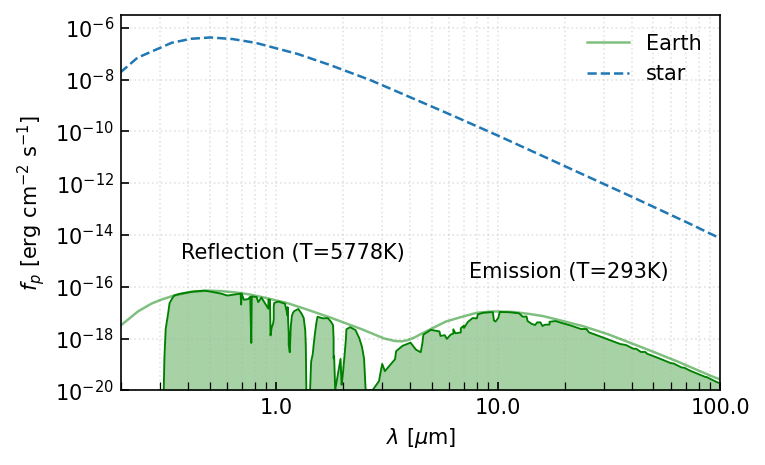

In [33]:
from turtle import color


fig, ax = plt.subplots(figsize=(5.2, 3.2), dpi=150)

# ---- 観測スペクトル：下パネル風の緑の塗りつぶし ＋ 外形線 ----
# 底辺をデータ最小の一桁下にしてログ塗りが崩れないように
y_floor = 10 ** (np.floor(np.log10(np.nanmin(e1[e1>0]))) - 1)
ax.fill_between(w1, e1, y_floor, alpha=0.35, linewidth=0, color="green")
ax.plot(w1, e1, lw=0.9, color="green")

# ---- 黒体：主星は破線，惑星は実線（図の雰囲気）----
ax.plot(w2, e2, ls="-", lw=1.2, label="Earth", alpha=0.5, color="green")
ax.plot(w3, e3, ls="--",  lw=1.2, label="star")
# ---- 軸・範囲・スケール ----
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=[1.0]))  
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(axis='x', style='plain')   # 10のべき乗を禁止

ax.set_xlim(0.3, 120)   # だいたい下パネルの横幅
# y範囲は見やすさ優先で少し余白を持たせる
y_min = 10 ** (np.floor(np.log10(np.nanmin([e1[e1>0].min(), e2[e2>0].min(), e3[e3>0].min()]))) - 1)
y_max = 10 ** (np.ceil (np.log10(np.nanmax([e1.max(), e2.max(), e3.max()]))) + 0.5)
ax.set_ylim(1.e-20, y_max)
ax.set_xlim(0.2,100.0)

ax.set_xlabel(r"$\lambda\ [{\mu}{\rm m}]$")
ax.set_ylabel(r"$f_p\ [{\rm erg}\ {\rm cm}^{-2}\ {\rm s}^{-1}]$")  # 既存"Emissivity"のままにしたければ変更しないでOK

# ---- 注記（位置は軸座標で指定; 必要なら微調整）----
ax.text(0.1, 0.35, "Reflection (T=5778K)", transform=ax.transAxes)
ax.text(0.58, 0.30, "Emission (T=293K)", transform=ax.transAxes)
ax.legend(loc="upper right", frameon=False)

# ---- グリッド/目盛り ----
ax.grid(True, which="both", ls=":", alpha=0.35)
ax.tick_params(which="both", direction="in", length=4)

plt.tight_layout()
plt.savefig("EarthEmis.png", dpi=300)
plt.show()

